<a href="https://colab.research.google.com/github/diogenesjusto/FIAP/blob/master/MBAIA/18DTSR/Aula1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
# Carga de bibliotecas
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [45]:
# Carga de dados
df = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/mtcars.csv")

<Axes: xlabel='wt', ylabel='mpg'>

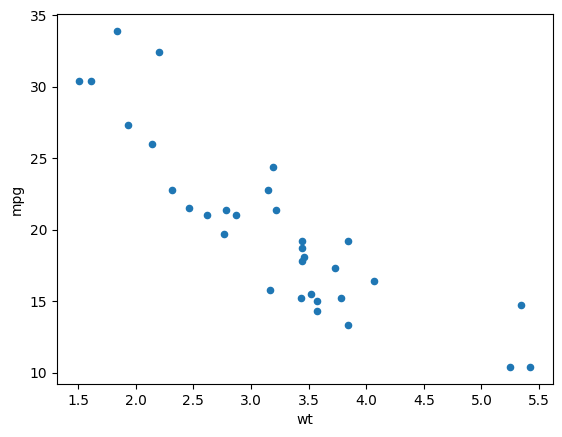

In [46]:
# Análise de correlação: gráfico de dispersão
df.plot.scatter(x="wt", y="mpg")

In [47]:
# Transformação de dados para colocar na mesma ordem de grandeza
#df['wt_t'] = df['wt']*6

# Ajuste de escala utilizando funções do SkLearn
scaler = MinMaxScaler(feature_range = (0,1))
df['wt_01'] = scaler.fit_transform(df[['wt']])
df['mpg_01'] = scaler.fit_transform(df[['mpg']])

<Axes: xlabel='wt', ylabel='mpg'>

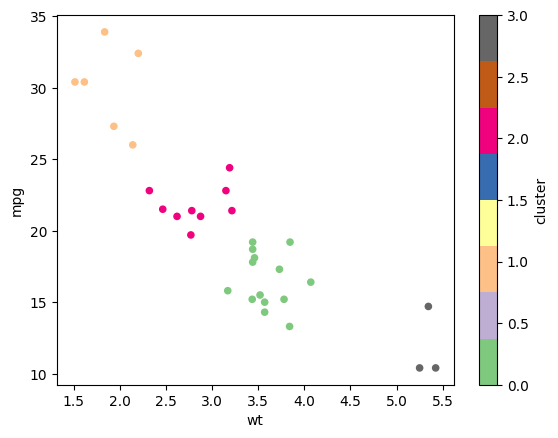

In [50]:
# Execução do K-Means
#k = KMeans(n_clusters=6, random_state=2).fit(df[["wt","mpg"]])
# Aplicando a nova "feature" wt transformada
k = KMeans(n_clusters=4, random_state=2).fit(df[["wt_01","mpg_01"]])

df['cluster'] = k.labels_

df.plot.scatter(x="wt", y="mpg", c='cluster', colormap='Accent')

In [52]:
# Feature Engineering no exercício
df

# 1. Cluster: é uma nova feature, que pode ser lida, por exemplo, como cluster=0 => veículos econômicos, etc
# Produto da execução de um algoritmo de aprend. não sup.
# 2. Transformação por pesos: demos um peso maior a variável wt (wt_t)
# 3. Transformação de escala: colocamos wt e mpg na mesma escala (wt_01, mpg_01)

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,wt_01,mpg_01,cluster
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,0.283048,0.451064,2
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,0.348249,0.451064,2
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,0.206341,0.527660,2
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,0.435183,0.468085,2
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,0.492713,0.353191,0
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1,0.497827,0.327660,0
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4,0.525952,0.165957,0
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2,0.428791,0.595745,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2,0.418563,0.527660,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4,0.492713,0.374468,0
